# ClariFi HMDA 2025: XGBoost Approval Model + SHAP

This notebook trains a narrowed mortgage-readiness model for ClariFi using 2025 HMDA Modified LAR data.

**Scope for the course project**
- Year: 2025 HMDA Modified LAR
- Geography: California (`state_code == 'CA'`)
- Loan type: home-purchase, owner-occupied, first-lien applications
- Target: approved/originated vs denied using `action_taken`
- Model: leakage-controlled XGBoost classifier with Logistic Regression baseline
- Fine tuning: probability calibration and balanced-threshold diagnostics
- Explanation: SHAP feature attributions

**Important modeling fixes**
- `interest_rate` is excluded because it is outcome-adjacent and can leak approval status.
- Applicant age, sex, race, and ethnicity are excluded from the readiness score and reserved only for fairness/audit discussion.
- XGBoost probabilities are calibrated on a separate calibration split before dashboard export.

**Retaining the trained model (Colab)**
- Setup mounts Google Drive and saves artifacts to `MyDrive/ClariFi/model_outputs/`.
- Section **9** exports `hmda_2025_xgboost_calibrated_pipeline.joblib` + `model_report.json`.
- Section **9B** downloads a zip for your repo (`public/data/model_outputs/`).
- On a new session, rerun setup only — Drive restore reloads the joblib automatically.

**Before running**
Download the 2025 HMDA Modified LAR CSV from FFIEC/CFPB and place it in `server/data/`, or use the repo sample `server/data/hmda_2025_sample_60000.csv`.

Recommended source: https://ffiec.cfpb.gov/data-publication/modified-lar


In [ ]:
# Install dependencies if needed. Run once per environment.
# If you already have these packages, you can skip this cell.
%pip install -q pandas numpy scikit-learn xgboost shap matplotlib seaborn pyarrow joblib scipy


In [ ]:
from pathlib import Path
import json
import shutil
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBClassifier
import shap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name == 'notebooks' else CWD

# Prefer the 60k model-ready sample for a fast class demo; fall back to the full HMDA file.
# If you run the Colab upload cell, DATA_PATH will be overwritten.
DATA_CANDIDATES = [
    PROJECT_ROOT / 'data' / 'hmda_2025_ca_model_ready_60000.csv',
    PROJECT_ROOT / 'server' / 'data' / 'hmda_2025_sample_60000.csv',
    PROJECT_ROOT / 'data' / 'hmda_2025_ca_sample_60000.csv',
    PROJECT_ROOT / 'data' / 'hmda_2025_modified_lar.csv',
]
DATA_PATH = next((candidate for candidate in DATA_CANDIDATES if candidate.exists()), DATA_CANDIDATES[-1])
OUTPUT_DIR = PROJECT_ROOT / 'public' / 'data' / 'model_outputs'
APP_DATA_DIR = PROJECT_ROOT / 'public' / 'data'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
APP_DATA_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = OUTPUT_DIR / 'hmda_2025_xgboost_calibrated_pipeline.joblib'
RAW_MODEL_PATH = OUTPUT_DIR / 'hmda_2025_xgboost_raw_pipeline.joblib'
APP_REPORT_PATH = APP_DATA_DIR / 'model_report.json'
DETAILED_REPORT_PATH = OUTPUT_DIR / 'hmda_2025_xgboost_shap_report.json'
INFERENCE_CONFIG_PATH = OUTPUT_DIR / 'scenario_inference_config.json'

# Colab: mount Google Drive so trained artifacts survive runtime disconnects.
PERSIST_DIR = None
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    try:
        from google.colab import drive

        drive.mount('/content/drive', force_remount=False)
        PERSIST_DIR = Path('/content/drive/MyDrive/ClariFi/model_outputs')
        PERSIST_DIR.mkdir(parents=True, exist_ok=True)
        print('Google Drive persist dir:', PERSIST_DIR)
    except Exception as exc:
        print('Drive mount skipped:', exc)


def restore_artifacts_from_drive() -> None:
    """Copy saved joblib + JSON from Drive into the active session if missing."""
    if PERSIST_DIR is None:
        return
    restore_pairs = [
        (PERSIST_DIR / MODEL_PATH.name, MODEL_PATH),
        (PERSIST_DIR / RAW_MODEL_PATH.name, RAW_MODEL_PATH),
        (PERSIST_DIR / APP_REPORT_PATH.name, APP_REPORT_PATH),
        (PERSIST_DIR / INFERENCE_CONFIG_PATH.name, INFERENCE_CONFIG_PATH),
        (PERSIST_DIR / DETAILED_REPORT_PATH.name, DETAILED_REPORT_PATH),
    ]
    for src, dest in restore_pairs:
        if src.exists() and not dest.exists():
            dest.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src, dest)
            print('Restored from Drive:', dest)


restore_artifacts_from_drive()

print('Project root:', PROJECT_ROOT)
print('Data path:', DATA_PATH)
print('Output dir:', OUTPUT_DIR)
print('Model artifact path:', MODEL_PATH)
if INFERENCE_CONFIG_PATH.exists():
    print('Existing inference config found — API will use notebook-export scoring.')
if MODEL_PATH.exists():
    print('Existing calibrated model found in session — you can reload it in section 9B instead of retraining.')


Mounted at /content/drive
Google Drive persist dir: /content/drive/MyDrive/ClariFi/model_outputs
Project root: /content
Data path: /content/data/hmda_2025_modified_lar.csv
Output dir: /content/public/data/model_outputs
Model artifact path: /content/public/data/model_outputs/hmda_2025_xgboost_calibrated_pipeline.joblib


In [ ]:
# Colab helper: upload the HMDA CSV into /content/sample_data and set DATA_PATH.
# Run this cell in Google Colab if your CSV is on your computer.
try:
    from google.colab import files
    from pathlib import Path

    SAMPLE_DATA_DIR = Path('/content/sample_data')
    SAMPLE_DATA_DIR.mkdir(parents=True, exist_ok=True)

    uploaded = files.upload()
    if uploaded:
        uploaded_name = next(iter(uploaded.keys()))
        source_path = Path(uploaded_name)
        target_path = SAMPLE_DATA_DIR / uploaded_name
        source_path.rename(target_path)
        DATA_PATH = target_path
        print(f'Uploaded file saved to: {DATA_PATH}')
    else:
        print('No file uploaded. DATA_PATH is unchanged:', DATA_PATH)
except ModuleNotFoundError:
    print('google.colab is not available. If running locally, place the CSV at:', DATA_PATH)


Saving hmda_2025_ca_model_ready_60000.csv to hmda_2025_ca_model_ready_60000.csv
Uploaded file saved to: /content/sample_data/hmda_2025_ca_model_ready_60000.csv


## 1. Load and Narrow 2025 HMDA Data

The national HMDA file can be very large. This loader reads only the columns we need and filters in chunks to keep memory usage manageable.

**Filters**
- California only
- Home purchase only: `loan_purpose == 1`
- Principal residence only: `occupancy_type == 1`
- First lien only: `lien_status == 1`
- Approval/denial target only: `action_taken in {1, 2, 3}`

**Target label**
- `1` = originated or approved-not-accepted
- `0` = denied

In [ ]:
USE_COLUMNS = [
    'activity_year', 'state_code', 'county_code', 'derived_msa-md', 'derived_msa_md',
    'loan_purpose', 'occupancy_type', 'lien_status', 'loan_type', 'action_taken',
    'loan_amount', 'income', 'property_value', 'debt_to_income_ratio',
    'combined_loan_to_value_ratio', 'interest_rate', 'loan_term',
    'applicant_age', 'applicant_sex', 'derived_race', 'derived_ethnicity',
    'ffiec_msa_md_median_family_income', 'tract_to_msa_income_percentage',
]

HMDA_85_COLUMNS = [
    'activity_year','lei','loan_type','loan_purpose','preapproval','construction_method','occupancy_type',
    'loan_amount','action_taken','state_code','county_code','census_tract','applicant_ethnicity_1',
    'applicant_ethnicity_2','applicant_ethnicity_3','applicant_ethnicity_4','applicant_ethnicity_5',
    'co_applicant_ethnicity_1','co_applicant_ethnicity_2','co_applicant_ethnicity_3','co_applicant_ethnicity_4',
    'co_applicant_ethnicity_5','applicant_ethnicity_observed','co_applicant_ethnicity_observed',
    'applicant_race_1','applicant_race_2','applicant_race_3','applicant_race_4','applicant_race_5',
    'co_applicant_race_1','co_applicant_race_2','co_applicant_race_3','co_applicant_race_4',
    'co_applicant_race_5','applicant_race_observed','co_applicant_race_observed','applicant_sex',
    'co_applicant_sex','applicant_sex_observed','co_applicant_sex_observed','applicant_age','co_applicant_age',
    'applicant_age_above_62','co_applicant_age_above_62','income','purchaser_type','rate_spread',
    'hoepa_status','lien_status','applicant_credit_score_type','co_applicant_credit_score_type',
    'denial_reason_1','denial_reason_2','denial_reason_3','denial_reason_4','total_loan_costs',
    'total_points_and_fees','origination_charges','discount_points','lender_credits','interest_rate',
    'prepayment_penalty_term','debt_to_income_ratio','combined_loan_to_value_ratio','loan_term',
    'intro_rate_period','negative_amortization','interest_only_payment','balloon_payment',
    'other_nonamortizing_features','property_value','manufactured_home_secured_property_type',
    'manufactured_home_land_property_interest','total_units','multifamily_affordable_units',
    'submission_of_application','initially_payable_to_institution','aus_1','aus_2','aus_3','aus_4','aus_5',
    'reverse_mortgage','open_end_line_of_credit','business_or_commercial_purpose'
]

def normalize_columns(df):
    return df.rename(columns={'derived_msa_md': 'derived_msa-md'})

def detect_pipe_no_header(path):
    with open(path, encoding='utf-8', errors='replace') as f:
        first = f.readline().strip()
    return '|' in first and first.split('|')[0].isdigit()

def load_hmda_ca_subset(path, chunksize=250_000, max_rows=None, filter_ca=True, filter_model_scope=True):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'Could not find {path}. Upload/download HMDA CSV and update DATA_PATH.')

    pipe_no_header = detect_pipe_no_header(path)
    read_kwargs = {'chunksize': chunksize, 'low_memory': False}
    if pipe_no_header:
        read_kwargs.update({'sep': '|', 'header': None, 'names': HMDA_85_COLUMNS})
    else:
        read_kwargs.update({'usecols': lambda c: c in USE_COLUMNS})

    chunks, total_seen, kept = [], 0, 0
    for i, chunk in enumerate(pd.read_csv(path, **read_kwargs), start=1):
        chunk = normalize_columns(chunk)
        total_seen += len(chunk)

        mask = pd.Series(True, index=chunk.index)
        if 'activity_year' in chunk.columns:
            mask &= pd.to_numeric(chunk['activity_year'], errors='coerce').eq(2025)
        if filter_ca and 'state_code' in chunk.columns:
            mask &= chunk['state_code'].astype(str).eq('CA')
        if filter_model_scope:
            mask &= pd.to_numeric(chunk['loan_purpose'], errors='coerce').eq(1)
            mask &= pd.to_numeric(chunk['occupancy_type'], errors='coerce').eq(1)
            mask &= pd.to_numeric(chunk['lien_status'], errors='coerce').eq(1)
            mask &= pd.to_numeric(chunk['action_taken'], errors='coerce').isin([1, 2, 3])

        filtered = chunk.loc[mask].copy()
        chunks.append(filtered)
        kept += len(filtered)
        if i % 10 == 0:
            print(f'Processed {total_seen:,} rows; kept {kept:,} rows')
        if max_rows and kept >= max_rows:
            break

    out = pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()
    if max_rows:
        out = out.head(max_rows)
    print(f'Final subset: {len(out):,} rows from {total_seen:,} scanned rows')
    return out

# The model-ready 60k file is already filtered, so this is fast. The full file works too.
hmda_raw = load_hmda_ca_subset(DATA_PATH, chunksize=250_000, max_rows=None, filter_ca=True, filter_model_scope=True)
hmda_raw.head()


Final subset: 58,012 rows from 60,000 scanned rows


,activity_year,loan_type,loan_purpose,occupancy_type,loan_amount,action_taken,state_code,county_code,applicant_sex,applicant_age,income,lien_status,interest_rate,debt_to_income_ratio,combined_loan_to_value_ratio,loan_term,property_value
0,2025,3,1,1,515000,3,CA,6071.0,2,55-64,98.0,1,NaN,50%-60%,103.30,360,495000
1,2025,1,1,1,765000,3,CA,6073.0,1,35-44,370.0,1,NaN,46,94.00,360,815000
2,2025,1,1,1,595000,3,CA,6073.0,2,25-34,183.0,1,NaN,30%-<36%,80.00,360,745000
3,2025,2,1,1,685000,3,CA,6065.0,1,25-34,232.0,1,NaN,>60%,97.68,360,705000
4,2025,2,1,1,395000,2,CA,6099.0,1,25-34,93.0,1,6.250,40,96.50,360,405000


## 2. Clean Features

HMDA fields often include strings such as `Exempt`, `NA`, or ratio ranges. The helpers below convert the modeling fields into usable numeric or categorical features.

In [ ]:
def to_number(series):
    return pd.to_numeric(
        series.astype(str).str.replace(',', '', regex=False).str.replace('%', '', regex=False),
        errors='coerce'
    )

def parse_dti(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().replace('%', '')
    if text.lower() in {'exempt', 'na', 'nan', ''}:
        return np.nan
    if text.startswith('<'):
        return 15.0
    if text.startswith('>'):
        return 55.0
    if '-' in text:
        nums = [pd.to_numeric(p, errors='coerce') for p in text.replace('<', '').split('-') if p]
        nums = [n for n in nums if pd.notna(n)]
        if nums:
            return float(np.mean(nums))
    return pd.to_numeric(text, errors='coerce')

def add_quantile_feature(df, source_col, new_col, q=10):
    try:
        df[new_col] = pd.qcut(df[source_col], q=q, labels=False, duplicates='drop').astype('float')
    except ValueError:
        df[new_col] = np.nan
    return df

def clean_hmda(df):
    df = df.copy()
    df['approved'] = pd.to_numeric(df['action_taken'], errors='coerce').isin([1, 2]).astype(int)

    numeric_raw = ['loan_amount','income','property_value','combined_loan_to_value_ratio','interest_rate','loan_term','ffiec_msa_md_median_family_income','tract_to_msa_income_percentage']
    for col in numeric_raw:
        if col in df.columns:
            df[col] = to_number(df[col])

    df['dti_numeric'] = df['debt_to_income_ratio'].apply(parse_dti)
    df['annual_income_dollars'] = df['income'] * 1000
    df['loan_to_income'] = df['loan_amount'] / df['annual_income_dollars'].replace(0, np.nan)
    df['down_payment_proxy'] = df['property_value'] - df['loan_amount']
    df['down_payment_rate_proxy'] = df['down_payment_proxy'] / df['property_value'].replace(0, np.nan)
    df['log_income'] = np.log1p(df['income'].clip(lower=0))
    df['log_loan_amount'] = np.log1p(df['loan_amount'].clip(lower=0))
    df['log_property_value'] = np.log1p(df['property_value'].clip(lower=0))
    df['high_dti_flag'] = (df['dti_numeric'] >= 43).astype(float)
    df['high_ltv_flag'] = (df['combined_loan_to_value_ratio'] >= 90).astype(float)
    df['jumbo_proxy_flag'] = (df['loan_amount'] >= 766_550).astype(float)

    # County-level context features computed only from training-like public fields.
    county_stats = df.groupby('county_code').agg(
        county_applications=('approved', 'size'),
        county_median_income=('income', 'median'),
        county_median_loan=('loan_amount', 'median'),
    )
    df = df.merge(county_stats, on='county_code', how='left')
    df['income_vs_county_median'] = df['income'] / df['county_median_income'].replace(0, np.nan)
    df['loan_vs_county_median'] = df['loan_amount'] / df['county_median_loan'].replace(0, np.nan)

    df = add_quantile_feature(df, 'income', 'income_decile')
    df = add_quantile_feature(df, 'loan_amount', 'loan_amount_decile')

    categorical_cols = ['county_code','derived_msa-md','loan_type','applicant_age','applicant_sex','derived_race','derived_ethnicity']
    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].astype('string').fillna('Missing')

    return df

hmda = clean_hmda(hmda_raw)
print(hmda.shape)
hmda[['approved','loan_amount','income','property_value','dti_numeric','combined_loan_to_value_ratio','loan_to_income','down_payment_rate_proxy']].describe()


(58012, 36)


,approved,loan_amount,income,property_value,dti_numeric,combined_loan_to_value_ratio,loan_to_income,down_payment_rate_proxy
count,58012.000000,5.801200e+04,57400.000000,5.750500e+04,56885.000000,53949.000000,57170.000000,57505.000000
mean,0.901572,6.703230e+05,242.525052,8.940300e+05,41.435985,80.446603,3.474421,0.194799
std,0.297895,5.659909e+05,581.882416,8.774797e+05,9.545772,18.095408,18.707784,0.267841
min,0.000000,5.000000e+03,-2006.000000,5.000000e+03,15.000000,3.000000,-4005.000000,-42.000000
25%,1.000000,3.750000e+05,110.000000,4.650000e+05,36.000000,74.580000,2.476852,0.045802
50%,1.000000,5.450000e+05,161.000000,6.750000e+05,43.000000,80.000000,3.329697,0.192090
75%,1.000000,7.850000e+05,256.000000,1.005000e+06,48.000000,95.000000,4.136364,0.260163
max,1.000000,1.650500e+07,65338.000000,3.000500e+07,55.000000,337.352000,505.000000,0.994286


In [ ]:
approval_rate = hmda['approved'].mean()
print(f'Approval positive-class rate: {approval_rate:.2%}')
display(hmda['approved'].value_counts(dropna=False).rename(index={0: 'Denied', 1: 'Approved / originated'}))

county_summary = (
    hmda.groupby('county_code')
    .agg(applications=('approved', 'size'), approval_rate=('approved', 'mean'), median_income=('income', 'median'), median_loan=('loan_amount', 'median'))
    .sort_values('applications', ascending=False)
)
county_summary.head(15)

Approval positive-class rate: 90.16%


,count
approved,
Approved / originated,52302
Denied,5710


,applications,approval_rate,median_income,median_loan
county_code,,,,
6037.0,9299,0.882568,192.0,685000.0
6065.0,5659,0.879484,137.0,505000.0
6073.0,5109,0.896457,188.0,685000.0
6071.0,3987,0.897667,128.0,465000.0
6059.0,3550,0.899155,230.0,795000.0
6067.0,3341,0.914397,132.0,445000.0
6085.0,2591,0.914705,312.5,1035000.0
6001.0,2251,0.924922,236.0,775000.0
6013.0,2035,0.913514,189.0,635000.0


## 2A. EDA: Data Quality, Outcome Balance, and Market Structure

This EDA is important for the visual analytics story. It shows whether the narrowed dataset is large enough, which fields are missing, how imbalanced approval/denial outcomes are, and which counties dominate the modeling sample.

Rows, columns: (58012, 36)
Approval rate: 90.16%


,value
rows,58012.000000
columns,36.000000
approval_rate,0.901572
denial_rate,0.098428
counties,59.000000


,missing_percent
interest_rate,9.9
combined_loan_to_value_ratio,7.0
debt_to_income_ratio,1.9
dti_numeric,1.9
loan_to_income,1.5
income_vs_county_median,1.2
income,1.1
annual_income_dollars,1.1
log_income,1.1
income_decile,1.1


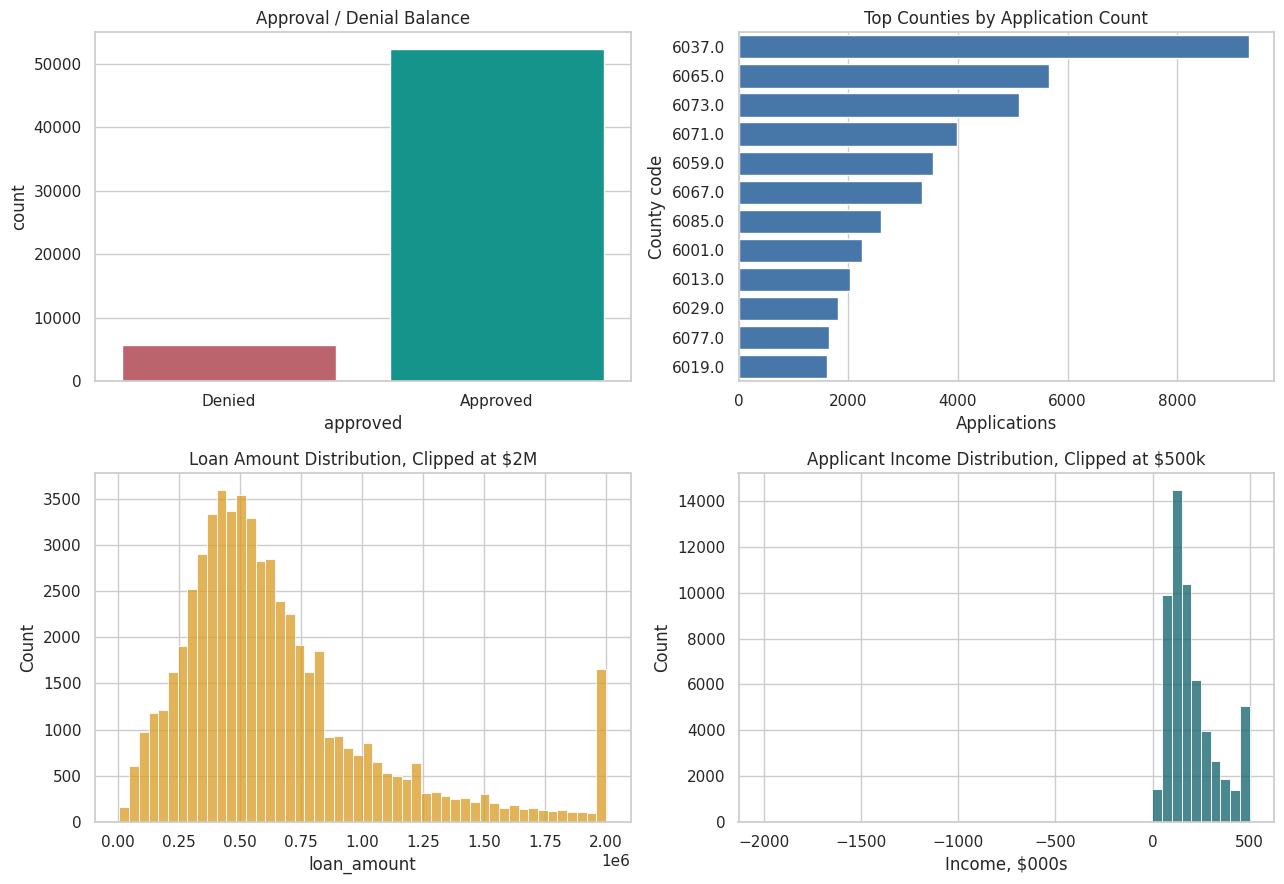

In [ ]:
print('Rows, columns:', hmda.shape)
print('Approval rate:', f"{hmda['approved'].mean():.2%}")

eda_summary = {
    'rows': int(len(hmda)),
    'columns': int(hmda.shape[1]),
    'approval_rate': float(hmda['approved'].mean()),
    'denial_rate': float(1 - hmda['approved'].mean()),
    'counties': int(hmda['county_code'].nunique()),
}
display(pd.Series(eda_summary, name='value'))

missing = (hmda.isna().mean().sort_values(ascending=False) * 100).round(1)
display(missing.head(20).rename('missing_percent'))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.countplot(x='approved', data=hmda, ax=axes[0,0], palette=['#C95562', '#00A99D'])
axes[0,0].set_title('Approval / Denial Balance')
axes[0,0].set_xticklabels(['Denied', 'Approved'])

top_counties = hmda['county_code'].value_counts().head(12)
sns.barplot(x=top_counties.values, y=top_counties.index.astype(str), ax=axes[0,1], color='#3777B8')
axes[0,1].set_title('Top Counties by Application Count')
axes[0,1].set_xlabel('Applications')
axes[0,1].set_ylabel('County code')

sns.histplot(hmda['loan_amount'].clip(upper=2_000_000), bins=50, ax=axes[1,0], color='#D99A20')
axes[1,0].set_title('Loan Amount Distribution, Clipped at $2M')

sns.histplot(hmda['income'].clip(upper=500), bins=50, ax=axes[1,1], color='#0E5F68')
axes[1,1].set_title('Applicant Income Distribution, Clipped at $500k')
axes[1,1].set_xlabel('Income, $000s')
plt.tight_layout()
plt.show()


,applications,approval_rate,median_income,median_loan,median_dti,median_ltv
county_code,,,,,,
6037.0,9299,0.882568,192.0,685000.0,43.0,80.0000
6065.0,5659,0.879484,137.0,505000.0,45.0,92.1585
6073.0,5109,0.896457,188.0,685000.0,43.0,80.0000
6071.0,3987,0.897667,128.0,465000.0,45.0,95.0000
6059.0,3550,0.899155,230.0,795000.0,42.0,79.2090
6067.0,3341,0.914397,132.0,445000.0,42.0,87.0190
6085.0,2591,0.914705,312.5,1035000.0,40.0,75.0000
6001.0,2251,0.924922,236.0,775000.0,40.0,80.0000
6013.0,2035,0.913514,189.0,635000.0,42.0,80.0000


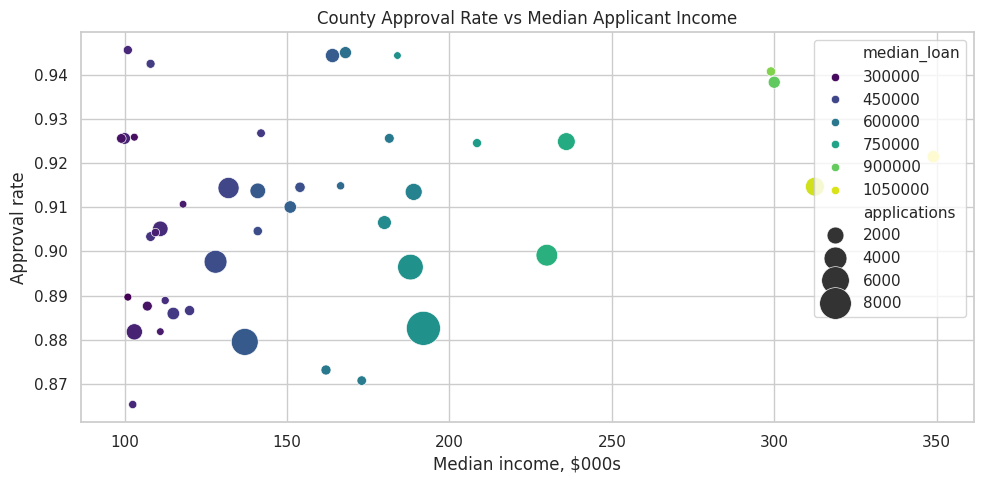

In [ ]:
county_summary = (
    hmda.groupby('county_code')
    .agg(
        applications=('approved', 'size'),
        approval_rate=('approved', 'mean'),
        median_income=('income', 'median'),
        median_loan=('loan_amount', 'median'),
        median_dti=('dti_numeric', 'median'),
        median_ltv=('combined_loan_to_value_ratio', 'median'),
    )
    .sort_values('applications', ascending=False)
)
display(county_summary.head(15))

county_model_sample = county_summary[county_summary['applications'] >= 100].copy()
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=county_model_sample, x='median_income', y='approval_rate',
    size='applications', sizes=(30, 600), hue='median_loan', palette='viridis', legend='brief'
)
plt.title('County Approval Rate vs Median Applicant Income')
plt.xlabel('Median income, $000s')
plt.ylabel('Approval rate')
plt.tight_layout()
plt.show()


## 2B. Leakage and Fairness Feature Policy

For the ClariFi readiness layer, the model should use fields that plausibly describe the application at scoring time. It should not learn from fields that are created after lender action or that act as shortcuts for the outcome.

**Excluded from prediction**
- `interest_rate`: outcome-adjacent and missing for many denied applications, so it can leak approval status.
- Race, ethnicity, sex, and age fields: useful for fairness/audit discussion, but not appropriate for the main consumer readiness score.

These fields can still appear in EDA or model-risk discussion, but they are not used by the XGBoost readiness model below.


## 3. Train/Test Split and Preprocessing

The model predicts whether an application is approved/originated or denied using a narrowed set of borrower, loan, and geography features.

In [ ]:
# Outcome-adjacent / leakage-prone fields excluded from scoring.
LEAKAGE_EXCLUDED_NUMERIC = [
    'interest_rate',
    'rate_spread',
    'total_loan_costs',
    'origination_charges',
    'discount_points',
    'lender_credits',
]

# Sensitive fields kept out of the readiness score. Use only for fairness/audit analysis if needed.
FAIRNESS_AUDIT_ONLY_CATEGORICAL = [
    'applicant_age',
    'applicant_sex',
    'derived_race',
    'derived_ethnicity',
]

FEATURES_NUMERIC = [
    'loan_amount', 'income', 'property_value', 'dti_numeric', 'combined_loan_to_value_ratio',
    'loan_term', 'loan_to_income', 'down_payment_rate_proxy',
    'log_income', 'log_loan_amount', 'log_property_value',
    'high_dti_flag', 'high_ltv_flag', 'jumbo_proxy_flag',
    'income_vs_county_median', 'loan_vs_county_median',
    'county_applications', 'county_median_income', 'county_median_loan',
    'income_decile', 'loan_amount_decile',
    'ffiec_msa_md_median_family_income', 'tract_to_msa_income_percentage',
]
FEATURES_CATEGORICAL = ['county_code', 'derived_msa-md', 'loan_type']

available_numeric = [c for c in FEATURES_NUMERIC if c in hmda.columns and c not in LEAKAGE_EXCLUDED_NUMERIC]
available_categorical = [c for c in FEATURES_CATEGORICAL if c in hmda.columns and c not in FAIRNESS_AUDIT_ONLY_CATEGORICAL]
features = available_numeric + available_categorical

model_df = hmda[features + ['approved']].dropna(subset=['approved']).copy()
X = model_df[features]
y = model_df['approved'].astype(int)

# Three-way split: tune/train, calibrate probabilities, then evaluate once on untouched test data.
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_train, X_cal, y_train, y_cal = train_test_split(
    X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=RANDOM_STATE
)

numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=50))])
preprocess = ColumnTransformer(transformers=[('num', numeric_transformer, available_numeric), ('cat', categorical_transformer, available_categorical)])

print('Train rows:', len(X_train), 'Calibration rows:', len(X_cal), 'Test rows:', len(X_test))
print('Positive rate train/cal/test:', y_train.mean().round(3), y_cal.mean().round(3), y_test.mean().round(3))
print('Excluded leakage-prone numeric fields present:', [c for c in LEAKAGE_EXCLUDED_NUMERIC if c in hmda.columns])
print('Excluded fairness-audit fields present:', [c for c in FAIRNESS_AUDIT_ONLY_CATEGORICAL if c in hmda.columns])
print('Numeric features:', available_numeric)
print('Categorical features:', available_categorical)


Train rows: 37127 Calibration rows: 9282 Test rows: 11603
Positive rate train/cal/test: 0.902 0.902 0.902
Excluded leakage-prone numeric fields present: ['interest_rate']
Excluded fairness-audit fields present: ['applicant_age', 'applicant_sex']
Numeric features: ['loan_amount', 'income', 'property_value', 'dti_numeric', 'combined_loan_to_value_ratio', 'loan_term', 'loan_to_income', 'down_payment_rate_proxy', 'log_income', 'log_loan_amount', 'log_property_value', 'high_dti_flag', 'high_ltv_flag', 'jumbo_proxy_flag', 'income_vs_county_median', 'loan_vs_county_median', 'county_applications', 'county_median_income', 'county_median_loan', 'income_decile', 'loan_amount_decile']
Categorical features: ['county_code', 'loan_type']


## 3A. Complex EDA: Mutual Information and Risk Surface

This cell quantifies nonlinear feature relevance before model training and builds a two-dimensional approval surface for DTI and LTV. These outputs support the interactive dashboard: feature ranking, risk heatmap, and what-if controls.


,feature,mutual_information
3,dti_numeric,0.033083
6,loan_to_income,0.020509
14,income_vs_county_median,0.020013
5,loan_term,0.018826
8,log_income,0.015223
10,log_property_value,0.012941
19,income_decile,0.012778
11,high_dti_flag,0.012632
15,loan_vs_county_median,0.011917
2,property_value,0.011563


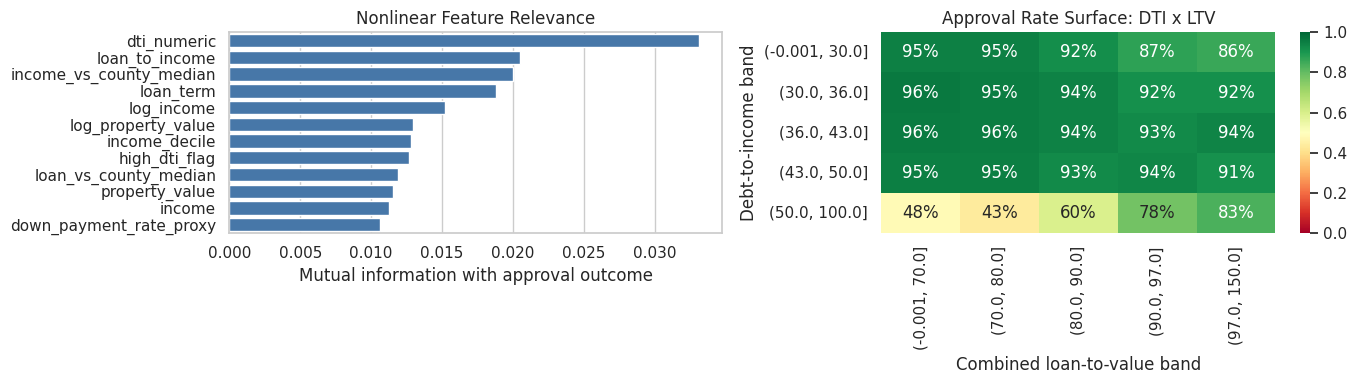

In [ ]:
numeric_for_mi = [c for c in available_numeric if c in X_train.columns]
mi_input = X_train[numeric_for_mi].copy()
for col in numeric_for_mi:
    mi_input[col] = pd.to_numeric(mi_input[col], errors='coerce')
mi_input = mi_input.replace([np.inf, -np.inf], np.nan).fillna(mi_input.median(numeric_only=True))

mi_scores = pd.DataFrame({
    'feature': numeric_for_mi,
    'mutual_information': mutual_info_classif(mi_input, y_train, random_state=RANDOM_STATE),
}).sort_values('mutual_information', ascending=False)

display(mi_scores.head(15))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=mi_scores.head(12), x='mutual_information', y='feature', ax=axes[0], color='#3777B8')
axes[0].set_title('Nonlinear Feature Relevance')
axes[0].set_xlabel('Mutual information with approval outcome')
axes[0].set_ylabel('')

risk_surface = hmda.copy()
risk_surface['dti_band'] = pd.cut(risk_surface['dti_numeric'], bins=[0, 30, 36, 43, 50, 100], include_lowest=True)
risk_surface['ltv_band'] = pd.cut(risk_surface['combined_loan_to_value_ratio'], bins=[0, 70, 80, 90, 97, 150], include_lowest=True)
risk_pivot = risk_surface.pivot_table(
    index='dti_band', columns='ltv_band', values='approved', aggfunc='mean', observed=False
)
sns.heatmap(risk_pivot, annot=True, fmt='.0%', cmap='RdYlGn', vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Approval Rate Surface: DTI x LTV')
axes[1].set_xlabel('Combined loan-to-value band')
axes[1].set_ylabel('Debt-to-income band')
plt.tight_layout()
plt.show()


## 3B. Baseline Model: Logistic Regression

A baseline model proves that XGBoost adds value beyond a simple interpretable classifier. The professor can see model comparison, not just one black-box result.

In [ ]:
baseline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE)),
])
baseline.fit(X_train, y_train)
baseline_proba = baseline.predict_proba(X_test)[:, 1]
baseline_pred = (baseline_proba >= 0.5).astype(int)
baseline_metrics = {
    'model': 'Logistic Regression baseline',
    'auc': float(roc_auc_score(y_test, baseline_proba)),
    'average_precision': float(average_precision_score(y_test, baseline_proba)),
    'f1': float(f1_score(y_test, baseline_pred)),
    'balanced_accuracy': float(balanced_accuracy_score(y_test, baseline_pred)),
}
baseline_metrics


{'model': 'Logistic Regression baseline',
 'auc': 0.7290717954822106,
 'average_precision': 0.9507509356457712,
 'f1': 0.7929805013927577,
 'balanced_accuracy': 0.6772960898381462}

## 4. XGBoost Model Selection

Use a small randomized search first. If the subset is very large, reduce `n_iter` or sample the training set for tuning, then retrain the best pipeline on all training rows.

In [ ]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    tree_method='hist',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
)

pipe = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', xgb),
])

# Conservative grid after leakage removal. This reduces overfitting and makes the result more defensible.
param_dist = {
    'model__n_estimators': [200, 350, 500],
    'model__max_depth': [2, 3, 4],
    'model__learning_rate': [0.02, 0.04, 0.06, 0.08],
    'model__subsample': [0.70, 0.85, 1.0],
    'model__colsample_bytree': [0.65, 0.80, 1.0],
    'model__min_child_weight': [5, 10, 20],
    'model__gamma': [0, 0.5, 1.0],
    'model__reg_alpha': [0, 0.1, 0.5],
    'model__reg_lambda': [3, 6, 10, 15],
}

RANDOM_SEARCH_ITERATIONS = 25
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=RANDOM_SEARCH_ITERATIONS,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
)

search.fit(X_train, y_train)
print('Best CV AUC:', search.best_score_)
print('Best params:', search.best_params_)

raw_best_model = search.best_estimator_
raw_cal_proba = raw_best_model.predict_proba(X_cal)[:, 1]

# The raw XGBoost ranking is useful, but class weighting makes probabilities under-calibrated.
# Isotonic calibration fixes the probability scale for dashboard use.
try:
    # scikit-learn <= 1.5 uses cv='prefit' for calibrating an already-fitted estimator.
    calibrated_model = CalibratedClassifierCV(raw_best_model, method='isotonic', cv='prefit')
    calibrated_model.fit(X_cal, y_cal)
except Exception as exc:
    # scikit-learn >= 1.6 prefers FrozenEstimator instead of cv='prefit'.
    if exc.__class__.__name__ != 'InvalidParameterError' and 'prefit' not in str(exc):
        raise
    from sklearn.frozen import FrozenEstimator

    calibrated_model = CalibratedClassifierCV(FrozenEstimator(raw_best_model), method='isotonic')
    calibrated_model.fit(X_cal, y_cal)

calibrated_cal_proba = calibrated_model.predict_proba(X_cal)[:, 1]

calibration_comparison = pd.DataFrame([
    {
        'model': 'Raw XGBoost',
        'calibration_auc': roc_auc_score(y_cal, raw_cal_proba),
        'calibration_brier': brier_score_loss(y_cal, raw_cal_proba),
        'mean_probability': raw_cal_proba.mean(),
        'actual_approval_rate': y_cal.mean(),
    },
    {
        'model': 'Calibrated XGBoost',
        'calibration_auc': roc_auc_score(y_cal, calibrated_cal_proba),
        'calibration_brier': brier_score_loss(y_cal, calibrated_cal_proba),
        'mean_probability': calibrated_cal_proba.mean(),
        'actual_approval_rate': y_cal.mean(),
    },
])
display(calibration_comparison)

best_model = calibrated_model
shap_model = raw_best_model


Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best CV AUC: 0.7967332534817189
Best params: {'model__subsample': 1.0, 'model__reg_lambda': 3, 'model__reg_alpha': 0, 'model__n_estimators': 200, 'model__min_child_weight': 5, 'model__max_depth': 4, 'model__learning_rate': 0.08, 'model__gamma': 0.5, 'model__colsample_bytree': 0.8}


,model,calibration_auc,calibration_brier,mean_probability,actual_approval_rate
0,Raw XGBoost,0.813647,0.145883,0.627441,0.90153
1,Calibrated XGBoost,0.817143,0.062639,0.901530,0.90153


## 5. Evaluate the Best Model

The proposal can report AUC, average precision, F1, accuracy, and calibration-style summaries.

,model,auc,average_precision,f1,balanced_accuracy,brier_score
0,Logistic Regression baseline,0.729072,0.950751,0.792981,0.677296,NaN
1,Raw XGBoost tuned,0.805521,0.965684,NaN,NaN,0.146493
2,Calibrated XGBoost tuned,0.804033,0.963682,0.874754,0.735237,0.063207


{
  "model": "XGBoost tuned + isotonic calibration",
  "test_auc": 0.8040326500013141,
  "raw_test_auc": 0.805521124162116,
  "average_precision": 0.9636824408601274,
  "raw_average_precision": 0.9656835716626441,
  "brier_score": 0.06320743893562601,
  "raw_brier_score": 0.146493154219279,
  "best_threshold_by_balanced_accuracy": 0.8999999999999999,
  "f1_at_best_threshold": 0.8747535540105842,
  "balanced_accuracy_at_best_threshold": 0.7352368843595702,
  "precision_at_best_threshold": 0.956541472824237,
  "recall_at_best_threshold": 0.8058503011184399,
  "denial_recall_at_best_threshold": 0.6646234676007006,
  "accuracy_at_best_threshold": 0.7919503576661209,
  "train_rows": 37127,
  "calibration_rows": 9282,
  "test_rows": 11603,
  "positive_rate_train": 0.9015810596062165,
  "positive_rate_calibration": 0.9015298427063133,
  "positive_rate_test": 0.9015771783159527
}
                     precision    recall  f1-score   support

             Denied       0.27      0.66      0.39   

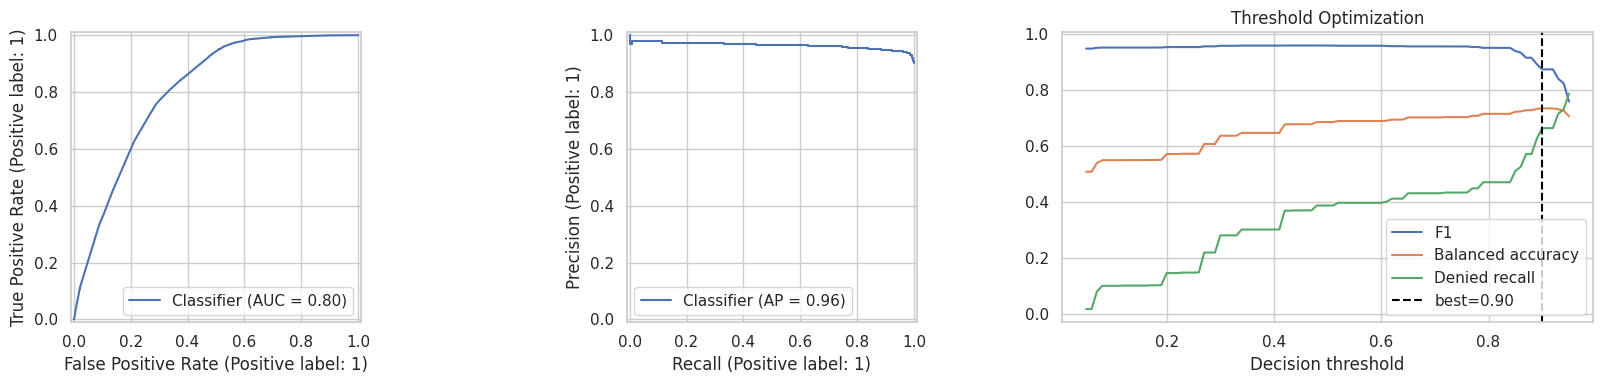

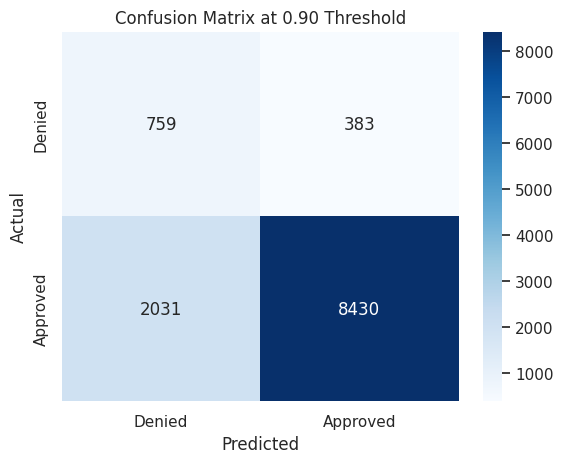

In [ ]:
proba = best_model.predict_proba(X_test)[:, 1]
raw_test_proba = raw_best_model.predict_proba(X_test)[:, 1]
threshold_grid = np.linspace(0.05, 0.95, 91)
threshold_scores = []
for threshold in threshold_grid:
    candidate = (proba >= threshold).astype(int)
    threshold_scores.append({
        'threshold': threshold,
        'f1': f1_score(y_test, candidate),
        'balanced_accuracy': balanced_accuracy_score(y_test, candidate),
        'precision': precision_score(y_test, candidate, zero_division=0),
        'recall': recall_score(y_test, candidate, zero_division=0),
        'denial_recall': recall_score(1 - y_test, 1 - candidate, zero_division=0),
    })
threshold_df = pd.DataFrame(threshold_scores)

# For this imbalanced dataset, balanced accuracy is a better diagnostic threshold than F1.
best_threshold = float(threshold_df.sort_values(['balanced_accuracy', 'f1'], ascending=False).iloc[0]['threshold'])
pred = (proba >= best_threshold).astype(int)

metrics = {
    'model': 'XGBoost tuned + isotonic calibration',
    'test_auc': float(roc_auc_score(y_test, proba)),
    'raw_test_auc': float(roc_auc_score(y_test, raw_test_proba)),
    'average_precision': float(average_precision_score(y_test, proba)),
    'raw_average_precision': float(average_precision_score(y_test, raw_test_proba)),
    'brier_score': float(brier_score_loss(y_test, proba)),
    'raw_brier_score': float(brier_score_loss(y_test, raw_test_proba)),
    'best_threshold_by_balanced_accuracy': best_threshold,
    'f1_at_best_threshold': float(f1_score(y_test, pred)),
    'balanced_accuracy_at_best_threshold': float(balanced_accuracy_score(y_test, pred)),
    'precision_at_best_threshold': float(precision_score(y_test, pred, zero_division=0)),
    'recall_at_best_threshold': float(recall_score(y_test, pred, zero_division=0)),
    'denial_recall_at_best_threshold': float(recall_score(1 - y_test, 1 - pred, zero_division=0)),
    'accuracy_at_best_threshold': float(accuracy_score(y_test, pred)),
    'train_rows': int(len(X_train)),
    'calibration_rows': int(len(X_cal)),
    'test_rows': int(len(X_test)),
    'positive_rate_train': float(y_train.mean()),
    'positive_rate_calibration': float(y_cal.mean()),
    'positive_rate_test': float(y_test.mean()),
}

model_comparison = pd.DataFrame([
    baseline_metrics,
    {
        'model': 'Raw XGBoost tuned',
        'auc': metrics['raw_test_auc'],
        'average_precision': metrics['raw_average_precision'],
        'f1': np.nan,
        'balanced_accuracy': np.nan,
        'brier_score': metrics['raw_brier_score'],
    },
    {
        'model': 'Calibrated XGBoost tuned',
        'auc': metrics['test_auc'],
        'average_precision': metrics['average_precision'],
        'f1': metrics['f1_at_best_threshold'],
        'balanced_accuracy': metrics['balanced_accuracy_at_best_threshold'],
        'brier_score': metrics['brier_score'],
    },
])
display(model_comparison)
print(json.dumps(metrics, indent=2))
print(classification_report(y_test, pred, target_names=['Denied', 'Approved/originated']))

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
RocCurveDisplay.from_predictions(y_test, proba, ax=axes[0])
PrecisionRecallDisplay.from_predictions(y_test, proba, ax=axes[1])
axes[2].plot(threshold_df['threshold'], threshold_df['f1'], label='F1')
axes[2].plot(threshold_df['threshold'], threshold_df['balanced_accuracy'], label='Balanced accuracy')
axes[2].plot(threshold_df['threshold'], threshold_df['denial_recall'], label='Denied recall')
axes[2].axvline(best_threshold, color='black', linestyle='--', label=f'best={best_threshold:.2f}')
axes[2].set_title('Threshold Optimization')
axes[2].set_xlabel('Decision threshold')
axes[2].legend()
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Denied', 'Approved'], yticklabels=['Denied', 'Approved'])
plt.title(f'Confusion Matrix at {best_threshold:.2f} Threshold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## 6. Calibration-Style Reliability Check

This bins predictions by probability and compares predicted approval rate with actual approval rate.

,bin,applications,predicted_rate,actual_rate,raw_predicted_rate
0,"(-0.001, 0.843]",1264,0.531703,0.537975,0.195187
1,"(0.843, 0.888]",1124,0.873110,0.882562,0.480899
2,"(0.888, 0.93]",1348,0.914957,0.910979,0.570460
3,"(0.93, 0.942]",1072,0.941601,0.940299,0.628004
4,"(0.942, 0.959]",1976,0.958576,0.954960,0.676055
5,"(0.959, 0.962]",799,0.961652,0.959950,0.711936
6,"(0.962, 0.968]",2804,0.968208,0.965763,0.760138
7,"(0.968, 0.98]",867,0.979948,0.979239,0.824101
8,"(0.98, 1.0]",349,0.992551,0.979943,0.871730


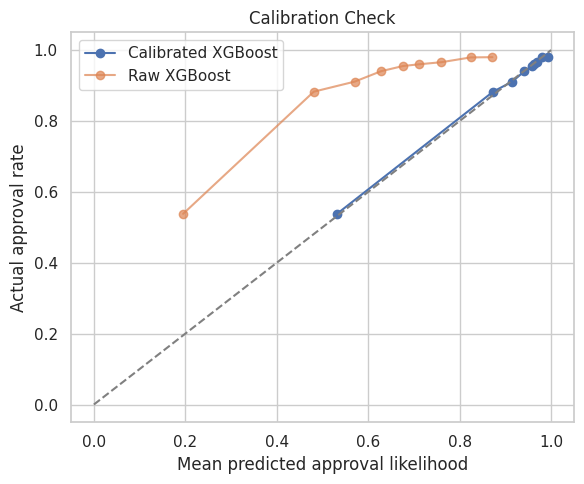

In [ ]:
cal = pd.DataFrame({'actual': y_test.values, 'predicted': proba, 'raw_predicted': raw_test_proba})
cal['bin'] = pd.qcut(cal['predicted'], q=10, duplicates='drop')
calibration = cal.groupby('bin').agg(
    applications=('actual', 'size'),
    predicted_rate=('predicted', 'mean'),
    actual_rate=('actual', 'mean'),
    raw_predicted_rate=('raw_predicted', 'mean'),
).reset_index()
display(calibration)

plt.figure(figsize=(6, 5))
plt.plot(calibration['predicted_rate'], calibration['actual_rate'], marker='o', label='Calibrated XGBoost')
plt.plot(calibration['raw_predicted_rate'], calibration['actual_rate'], marker='o', label='Raw XGBoost', alpha=0.7)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Mean predicted approval likelihood')
plt.ylabel('Actual approval rate')
plt.title('Calibration Check')
plt.legend()
plt.tight_layout()
plt.show()


## 6A. Segment Diagnostics for Visual Analytics

This checks whether the model behaves differently across counties and income groups. These outputs can power dashboard warnings and map overlays.

,test_rows,actual_approval_rate,predicted_approval_rate,error_rate,median_income,median_loan
county_code,,,,,,
6039.0,107,0.906542,0.888213,0.327103,120.5,415000.0
6029.0,353,0.875354,0.893010,0.300283,101.0,345000.0
6065.0,1131,0.883289,0.881865,0.289125,134.0,515000.0
6073.0,1051,0.892483,0.899827,0.256898,187.0,685000.0
6037.0,1843,0.881715,0.877478,0.245252,190.0,685000.0
6019.0,298,0.909396,0.909425,0.244966,110.0,395000.0
6071.0,810,0.892593,0.889226,0.240741,127.0,445000.0
6111.0,252,0.908730,0.913552,0.218254,182.0,645000.0
6053.0,78,0.858974,0.836338,0.217949,169.5,590000.0


,income_group,test_rows,actual_approval_rate,predicted_approval_rate,error_rate
0,"(-799.001, 100.0]",2341,0.824434,0.823452,0.329346
1,"(100.0, 138.0]",2272,0.897447,0.890662,0.260123
2,"(138.0, 188.0]",2279,0.926722,0.921019,0.206670
3,"(188.0, 292.0]",2295,0.925926,0.934857,0.143791
4,"(292.0, 44041.0]",2294,0.934176,0.940749,0.101133


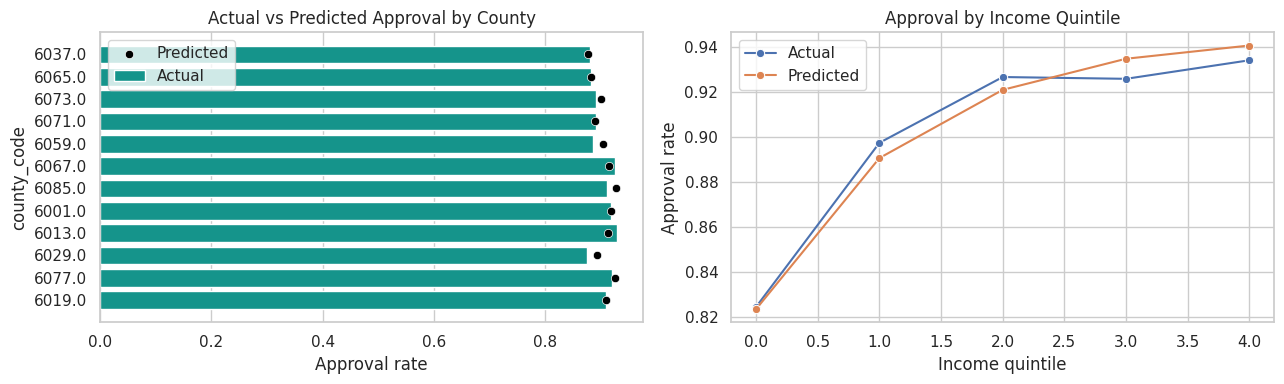

In [ ]:
diagnostic = X_test.copy()
diagnostic['actual'] = y_test.values
diagnostic['predicted_proba'] = proba
diagnostic['predicted_label'] = pred
diagnostic['error'] = (diagnostic['actual'] != diagnostic['predicted_label']).astype(int)
diagnostic['income_group'] = pd.qcut(diagnostic['income'], q=5, duplicates='drop')

county_diagnostics = (diagnostic.groupby('county_code')
    .agg(
        test_rows=('actual', 'size'),
        actual_approval_rate=('actual', 'mean'),
        predicted_approval_rate=('predicted_proba', 'mean'),
        error_rate=('error', 'mean'),
        median_income=('income', 'median'),
        median_loan=('loan_amount', 'median'),
    )
    .query('test_rows >= 50')
    .sort_values('error_rate', ascending=False)
)
display(county_diagnostics.head(15))

income_diagnostics = diagnostic.groupby('income_group').agg(
    test_rows=('actual', 'size'),
    actual_approval_rate=('actual', 'mean'),
    predicted_approval_rate=('predicted_proba', 'mean'),
    error_rate=('error', 'mean'),
).reset_index()
display(income_diagnostics)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_counties = county_diagnostics.sort_values('test_rows', ascending=False).head(12).reset_index()
sns.barplot(data=plot_counties, y='county_code', x='actual_approval_rate', color='#00A99D', ax=axes[0], label='Actual')
sns.scatterplot(data=plot_counties, y='county_code', x='predicted_approval_rate', color='black', ax=axes[0], label='Predicted')
axes[0].set_title('Actual vs Predicted Approval by County')
axes[0].set_xlabel('Approval rate')
axes[0].legend()

sns.lineplot(data=income_diagnostics, x=income_diagnostics.index, y='actual_approval_rate', marker='o', ax=axes[1], label='Actual')
sns.lineplot(data=income_diagnostics, x=income_diagnostics.index, y='predicted_approval_rate', marker='o', ax=axes[1], label='Predicted')
axes[1].set_title('Approval by Income Quintile')
axes[1].set_xlabel('Income quintile')
axes[1].set_ylabel('Approval rate')
plt.tight_layout()
plt.show()


## 7. SHAP Explanations

SHAP shows which transformed features push the XGBoost prediction toward approval or denial.

For large datasets, explain a sample of test rows rather than the full test set.

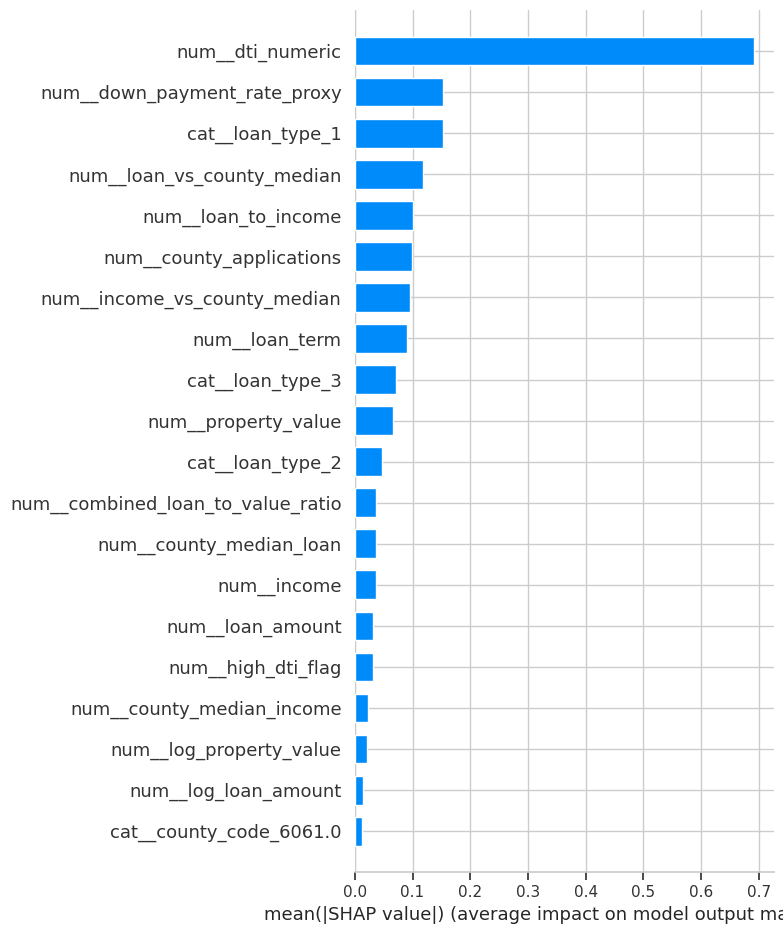

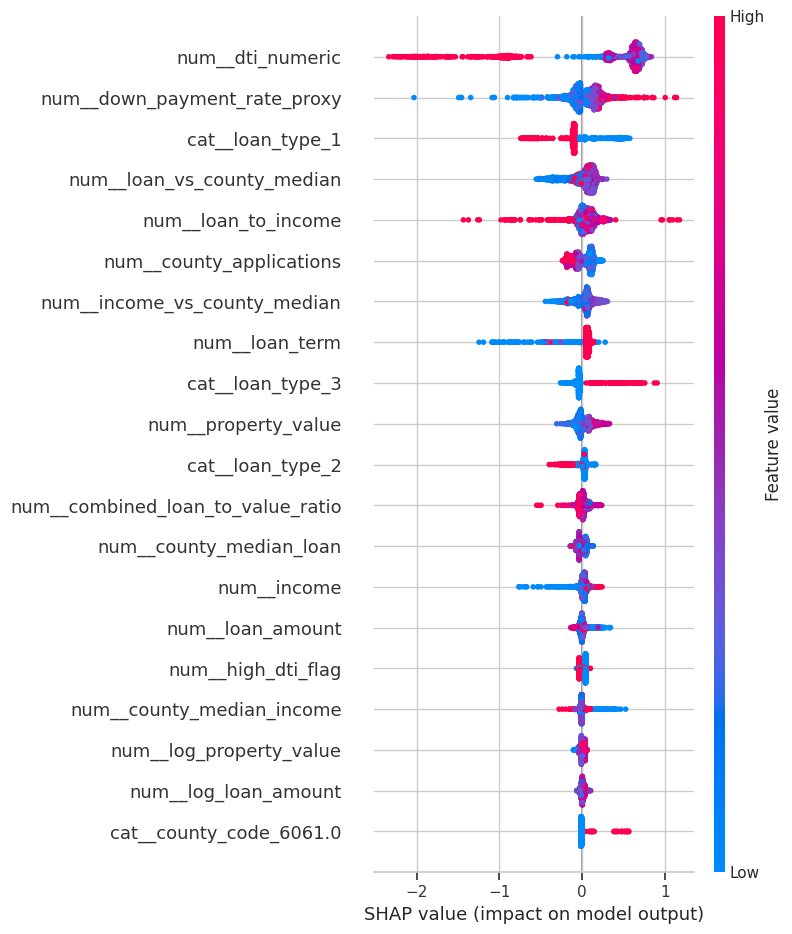

In [ ]:
preprocessor = shap_model.named_steps['preprocess']
xgb_model = shap_model.named_steps['model']

X_test_sample = X_test.sample(n=min(2000, len(X_test)), random_state=RANDOM_STATE)
X_test_transformed = preprocessor.transform(X_test_sample)

feature_names = preprocessor.get_feature_names_out()

# Convert sparse matrix to dense only for the SHAP sample.
if hasattr(X_test_transformed, 'toarray'):
    X_test_transformed_dense = X_test_transformed.toarray()
else:
    X_test_transformed_dense = X_test_transformed

explainer = shap.TreeExplainer(xgb_model)
shap_values_raw = explainer.shap_values(X_test_transformed_dense)
shap_values = shap_values_raw[1] if isinstance(shap_values_raw, list) else shap_values_raw

shap.summary_plot(shap_values, X_test_transformed_dense, feature_names=feature_names, plot_type='bar', max_display=20)
shap.summary_plot(shap_values, X_test_transformed_dense, feature_names=feature_names, max_display=20)


## 8. Explain One User-Like Scenario

This section creates an example explanation for one application row. Later, the dashboard can pass a user profile through the same pipeline.

Example calibrated approval likelihood: 95.9%
Example raw XGBoost approval likelihood: 64.9%


,loan_amount,income,property_value,dti_numeric,combined_loan_to_value_ratio,loan_term,loan_to_income,down_payment_rate_proxy,log_income,log_loan_amount,...,jumbo_proxy_flag,income_vs_county_median,loan_vs_county_median,county_applications,county_median_income,county_median_loan,income_decile,loan_amount_decile,county_code,loan_type
956,935000,494.0,955000.0,37.0,96.5,360.0,1.892713,0.020942,6.204558,13.748303,...,1.0,2.62766,1.364964,5109.0,188.0,685000.0,9.0,8.0,6073.0,2


,feature,shap_value
3,num__dti_numeric,0.381637
69,cat__loan_type_2,-0.181724
5,num__loan_term,0.078300
16,num__county_applications,-0.067043
7,num__down_payment_rate_proxy,0.066892
14,num__income_vs_county_median,0.065367
2,num__property_value,0.065125
15,num__loan_vs_county_median,0.064467
11,num__high_dti_flag,0.041679
9,num__log_loan_amount,0.039674


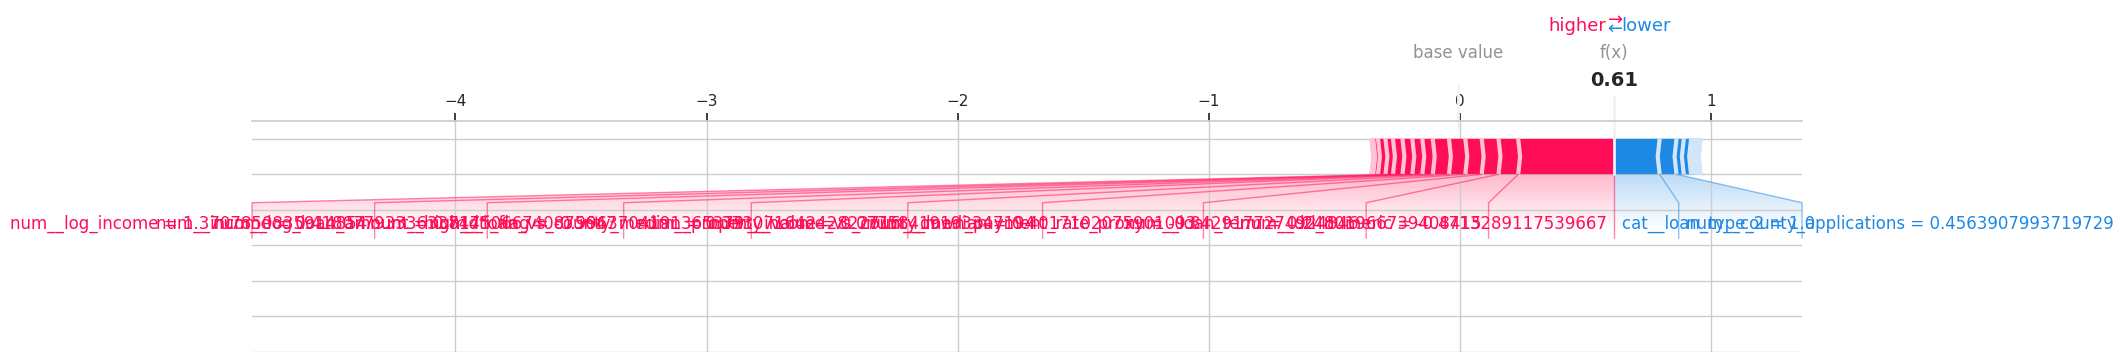

In [ ]:
example_idx = X_test_sample.index[0]
example_raw = X.loc[[example_idx]]
example_proba = best_model.predict_proba(example_raw)[:, 1][0]
example_raw_proba = shap_model.predict_proba(example_raw)[:, 1][0]
example_transformed = preprocessor.transform(example_raw)
example_dense = example_transformed.toarray() if hasattr(example_transformed, 'toarray') else example_transformed
example_shap_raw = explainer.shap_values(example_dense)
example_shap = (example_shap_raw[1] if isinstance(example_shap_raw, list) else example_shap_raw)[0]

expected_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) and np.ndim(explainer.expected_value) > 0 else explainer.expected_value

top = pd.DataFrame({
    'feature': feature_names,
    'shap_value': example_shap,
    'abs_shap': np.abs(example_shap),
}).sort_values('abs_shap', ascending=False).head(12)

print(f'Example calibrated approval likelihood: {example_proba:.1%}')
print(f'Example raw XGBoost approval likelihood: {example_raw_proba:.1%}')
display(example_raw)
display(top[['feature', 'shap_value']])

shap.force_plot(expected_value, example_shap, example_dense[0], feature_names=feature_names, matplotlib=True)


## 9. Export Model Outputs for the Dashboard

Writes everything ClariFi needs:

- **`hmda_2025_xgboost_calibrated_pipeline.joblib`** — scored by FastAPI (`calibrated-xgboost` mode)
- **`scenario_inference_config.json`** — county medians + decile edges for slider scenarios (`featureMode: notebook-export`)
- **`model_report.json`** — calibration curve + metrics for the React model panel (no global SHAP bar chart in UI)

Also saves a detailed SHAP report JSON and CSV diagnostics under `model_outputs/`.


In [ ]:
def clean_feature_label(feature):

    label = str(feature).replace('num__', '').replace('cat__', '')

    label = label.replace('derived_msa-md', 'MSA').replace('_', ' ')

    return label



global_shap = pd.DataFrame({

    'feature': feature_names,

    'label': [clean_feature_label(f) for f in feature_names],

    'mean_shap': np.mean(shap_values, axis=0),

    'mean_abs_shap': np.abs(shap_values).mean(axis=0),

}).sort_values('mean_abs_shap', ascending=False)



global_shap['direction'] = np.where(global_shap['mean_shap'] >= 0, 'positive', 'negative')



# Convert risk_pivot index and columns to strings for JSON serialization.

risk_pivot_for_json = risk_pivot.copy()

risk_pivot_for_json.index = risk_pivot_for_json.index.astype(str)

risk_pivot_for_json.columns = risk_pivot_for_json.columns.astype(str)



model_report = {

    'model_name': 'XGBoost HMDA 2025 California approval model - leakage controlled',

    'scope': {

        'year': 2025,

        'state': 'CA',

        'loan_purpose': 'Home purchase only',

        'occupancy': 'Principal residence only',

        'lien_status': 'First lien only',

        'target': 'Approved/originated vs denied using HMDA action_taken',

    },

    'feature_policy': {

        'excluded_leakage_fields': [c for c in LEAKAGE_EXCLUDED_NUMERIC if c in hmda.columns],

        'fairness_audit_only_fields': [c for c in FAIRNESS_AUDIT_ONLY_CATEGORICAL if c in hmda.columns],

        'used_numeric_features': available_numeric,

        'used_categorical_features': available_categorical,

    },

    'eda_summary': eda_summary,

    'metrics': metrics,

    'calibration_comparison': calibration_comparison.to_dict(orient='records'),

    'baseline_metrics': baseline_metrics,

    'model_comparison': model_comparison.to_dict(orient='records'),

    'best_params': search.best_params_,

    'top_shap_features': global_shap.head(25).to_dict(orient='records'),

    'calibration': calibration.assign(bin=calibration['bin'].astype(str)).to_dict(orient='records'),

    'county_summary': county_summary.reset_index().head(100).to_dict(orient='records'),

    'county_diagnostics': county_diagnostics.reset_index().head(100).to_dict(orient='records'),

    'income_diagnostics': income_diagnostics.assign(income_group=income_diagnostics['income_group'].astype(str)).to_dict(orient='records'),

    'mutual_information': mi_scores.head(25).to_dict(orient='records'),

    'risk_surface': risk_pivot_for_json.reset_index().to_dict(orient='records'),

}



report_path = DETAILED_REPORT_PATH

with open(report_path, 'w') as f:

    json.dump(model_report, f, indent=2)



# ClariFi API: export inference config so FastAPI scoring matches notebook features.

county_stats_export = (

    hmda.groupby('county_code')

    .agg(

        county_applications=('approved', 'size'),

        county_median_income=('income', 'median'),

        county_median_loan=('loan_amount', 'median'),

    )

    .reset_index()

)

income_decile_edges = pd.qcut(hmda['income'].dropna(), q=10, duplicates='drop', retbins=True)[1].tolist()

loan_decile_edges = pd.qcut(hmda['loan_amount'].dropna(), q=10, duplicates='drop', retbins=True)[1].tolist()

feature_defaults = {}

for col in available_numeric:

    if col in hmda.columns:

        feature_defaults[col] = float(hmda[col].median())

for col in available_categorical:

    if col in hmda.columns:

        feature_defaults[col] = str(hmda[col].mode(dropna=True).iloc[0])

inference_config = {

    'generatedAt': pd.Timestamp.utcnow().isoformat(),

    'source': 'Colab notebook export — canonical scoring artifact for ClariFi API',

    'numericFeatures': available_numeric,

    'categoricalFeatures': available_categorical,

    'marketCountyCode': {

        'Sacramento': '6067.0',

        'Alameda': '6001.0',

        'San Diego': '6073.0',

        'Los Angeles': '6037.0',

    },

    'countyStats': {

        str(row['county_code']): {

            'county_applications': int(row['county_applications']),

            'county_median_income': float(row['county_median_income']),

            'county_median_loan': float(row['county_median_loan']),

        }

        for row in county_stats_export.to_dict(orient='records')

    },

    'incomeDecileEdges': income_decile_edges,

    'loanDecileEdges': loan_decile_edges,

    'featureDefaults': feature_defaults,

    'globalShap': global_shap.head(25).to_dict(orient='records'),

}

inference_path = INFERENCE_CONFIG_PATH

with open(inference_path, 'w') as f:

    json.dump(inference_config, f, indent=2)

print('Saved API inference config:', inference_path)



joblib.dump(best_model, MODEL_PATH)

joblib.dump(shap_model, RAW_MODEL_PATH)



global_shap.to_csv(OUTPUT_DIR / 'hmda_2025_global_shap.csv', index=False)

county_diagnostics.reset_index().to_csv(OUTPUT_DIR / 'hmda_2025_county_diagnostics.csv', index=False)

calibration.assign(bin=calibration['bin'].astype(str)).to_csv(OUTPUT_DIR / 'hmda_2025_calibration.csv', index=False)

mi_scores.to_csv(OUTPUT_DIR / 'hmda_2025_mutual_information.csv', index=False)

risk_pivot.to_csv(OUTPUT_DIR / 'hmda_2025_dti_ltv_risk_surface.csv')



# App-compatible model report for the current ClariFi dashboard/backend.

app_model_report = {

    'generatedAt': pd.Timestamp.utcnow().isoformat(),

    'modelName': 'XGBoost HMDA 2025 readiness model',

    'note': 'Leakage-controlled HMDA model. Interest rate and sensitive demographic fields are excluded from the readiness score. Use for educational exploration, not lending advice.',

    'rows': {

        'total': int(len(model_df)),

        'train': int(len(X_train)),

        'calibration': int(len(X_cal)),

        'test': int(len(X_test)),

    },

    'metrics': {

        'trainAccuracy': None,

        'testAccuracy': metrics['accuracy_at_best_threshold'],

        'testAuc': metrics['test_auc'],

        'averagePrecision': metrics['average_precision'],

        'balancedAccuracy': metrics['balanced_accuracy_at_best_threshold'],

        'bestThreshold': metrics['best_threshold_by_balanced_accuracy'],

        'brierScore': metrics['brier_score'],

        'denialRecall': metrics['denial_recall_at_best_threshold'],

    },

    'features': [

        {

            'feature': row['feature'],

            'label': row['label'],

            'coefficient': float(row['mean_shap']),

            'direction': row['direction'],

            'magnitude': float(row['mean_abs_shap']),

        }

        for row in global_shap.head(12).to_dict(orient='records')

    ],

    'featurePolicy': model_report['feature_policy'],

    'countyCalibration': [

        {

            'county': str(row['county_code']),

            'rows': int(row['test_rows']),

            'actualApprovalRate': float(row['actual_approval_rate']),

            'predictedApprovalRate': float(row['predicted_approval_rate']),

            'errorRate': float(row['error_rate']),

        }

        for row in county_diagnostics.reset_index().head(100).to_dict(orient='records')

    ],

}



app_report_path = APP_REPORT_PATH

app_report_path.parent.mkdir(parents=True, exist_ok=True)

with open(app_report_path, 'w') as f:

    json.dump(app_model_report, f, indent=2)



ARTIFACT_PATHS = [

    MODEL_PATH,

    RAW_MODEL_PATH,

    report_path,

    app_report_path,

    inference_path,

    OUTPUT_DIR / 'hmda_2025_global_shap.csv',

    OUTPUT_DIR / 'hmda_2025_county_diagnostics.csv',

    OUTPUT_DIR / 'hmda_2025_calibration.csv',

    OUTPUT_DIR / 'hmda_2025_mutual_information.csv',

    OUTPUT_DIR / 'hmda_2025_dti_ltv_risk_surface.csv',

]





def persist_artifacts_to_drive(paths: list[Path]) -> list[Path]:

    """Copy trained artifacts to Google Drive for retention across Colab sessions."""

    if PERSIST_DIR is None:

        return []

    copied = []

    for path in paths:

        if not path.exists():

            continue

        dest = PERSIST_DIR / path.name

        shutil.copy2(path, dest)

        copied.append(dest)

    return copied







def verify_dashboard_scenario(model, config_path: Path) -> None:
    """Sanity-check the same feature path the ClariFi API uses after export."""
    try:
        sys.path.insert(0, str(PROJECT_ROOT))
        from scripts.scenario_inference import build_scenario_features, features_dataframe
    except ImportError as exc:
        print('Dashboard scenario check skipped (run from repo root):', exc)
        return

    class _Scenario:
        market = 'Sacramento'
        income = 9400
        debt = 1250
        savings = 82000
        price = 560000

    features, feature_mode = build_scenario_features(_Scenario())
    frame = features_dataframe(features, model)
    proba = float(model.predict_proba(frame)[:, 1][0])
    print(f'Dashboard scenario check ({feature_mode}): approval probability = {proba:.3f}')
    if config_path.exists():
        print('  inference config:', config_path.name)
    else:
        print('  WARNING: missing scenario_inference_config.json — API falls back to synthetic-local features')


verify_dashboard_scenario(best_model, inference_path)

drive_copies = persist_artifacts_to_drive(ARTIFACT_PATHS)



print('Saved detailed report:', report_path)

print('Saved calibrated model artifact:', MODEL_PATH)

print('Saved raw SHAP model artifact:', RAW_MODEL_PATH)

print('Saved app model report:', app_report_path)

if drive_copies:

    print(f'Copied {len(drive_copies)} files to Google Drive:', PERSIST_DIR)

else:

    print('Drive not mounted — artifacts exist only for this Colab session until you run section 9B.')

display(global_shap.head(15))



Saved API inference config: /content/public/data/model_outputs/scenario_inference_config.json
Dashboard scenario check skipped (run from repo root): No module named 'scripts'
Saved detailed report: /content/public/data/model_outputs/hmda_2025_xgboost_shap_report.json
Saved calibrated model artifact: /content/public/data/model_outputs/hmda_2025_xgboost_calibrated_pipeline.joblib
Saved raw SHAP model artifact: /content/public/data/model_outputs/hmda_2025_xgboost_raw_pipeline.joblib
Saved app model report: /content/public/data/model_report.json
Copied 10 files to Google Drive: /content/drive/MyDrive/ClariFi/model_outputs


,feature,label,mean_shap,mean_abs_shap,direction
3,num__dti_numeric,dti numeric,0.317683,0.691901,positive
7,num__down_payment_rate_proxy,down payment rate proxy,0.044697,0.153453,positive
68,cat__loan_type_1,loan type 1,-0.045051,0.152376,negative
15,num__loan_vs_county_median,loan vs county median,0.013775,0.118627,positive
6,num__loan_to_income,loan to income,0.040568,0.100088,positive
16,num__county_applications,county applications,0.008177,0.099834,positive
14,num__income_vs_county_median,income vs county median,0.027577,0.096038,positive
5,num__loan_term,loan term,0.036820,0.089800,positive
70,cat__loan_type_3,loan type 3,-0.011155,0.072160,negative
2,num__property_value,property value,0.022325,0.066468,positive


## 9B. Retain and download model artifacts

Colab runtimes are ephemeral. After section 9:

1. **Google Drive** — artifacts copy to `MyDrive/ClariFi/model_outputs/` (joblib + both JSON files).
2. **Download zip** — run the cell below, then copy into your repo:
   - `public/data/model_outputs/hmda_2025_xgboost_calibrated_pipeline.joblib`
   - `public/data/model_outputs/scenario_inference_config.json` ← **required for API feature alignment**
   - `public/data/model_report.json`
3. **Verify locally** — from repo root:
   ```bash
   npm run dev:api
   curl -s http://127.0.0.1:8001/api/health | python -m json.tool
   ```
   Expect `"modelLoaded": true`, `"inferenceConfigPresent": true`, `"scoringPipeline": "calibrated-xgboost"`.
   POST `/api/mortgage/score` should return `"mode": "calibrated-xgboost"` and `"featureMode": "notebook-export"`.
4. **Reload without retraining** — if artifacts exist (from Drive or prior run), rerun setup + section 9B reload cell.


In [ ]:
# Reload a previously saved calibrated pipeline (skip retraining).
if MODEL_PATH.exists():
    best_model = joblib.load(MODEL_PATH)
    print('Loaded calibrated model from:', MODEL_PATH)
    if 'X_test' in globals() and len(X_test) > 0:
        sample_proba = best_model.predict_proba(X_test.head(1))[:, 1][0]
        print(f'Sanity-check approval probability on one test row: {sample_proba:.3f}')
else:
    print('No saved model in this session. Run training (sections 4–9) first, or mount Drive and rerun setup.')

# Package artifacts for download / repo copy.
artifact_paths = [p for p in ARTIFACT_PATHS if p.exists()] if 'ARTIFACT_PATHS' in globals() else [
    MODEL_PATH,
    RAW_MODEL_PATH,
    APP_REPORT_PATH,
    INFERENCE_CONFIG_PATH,
    DETAILED_REPORT_PATH,
]

zip_staging = OUTPUT_DIR / 'clarifi_export'
if zip_staging.exists():
    shutil.rmtree(zip_staging)
zip_staging.mkdir(parents=True, exist_ok=True)

for path in artifact_paths:
    if path.exists():
        shutil.copy2(path, zip_staging / path.name)

zip_base = OUTPUT_DIR / 'clarifi_model_artifacts'
zip_file = Path(f'{zip_base}.zip')
if zip_file.exists():
    zip_file.unlink()
shutil.make_archive(str(zip_base), 'zip', zip_staging)

print('Local zip ready:', zip_file)
print('Copy into repo:')
print('  public/data/model_outputs/hmda_2025_xgboost_calibrated_pipeline.joblib')
print('  public/data/model_outputs/scenario_inference_config.json')
print('  public/data/model_report.json')

try:
    from google.colab import files

    files.download(str(zip_file))
except ModuleNotFoundError:
    print('Not in Colab — open the zip path above from your filesystem.')


Loaded calibrated model from: /content/public/data/model_outputs/hmda_2025_xgboost_calibrated_pipeline.joblib
Sanity-check approval probability on one test row: 0.930
Local zip ready: /content/public/data/model_outputs/clarifi_model_artifacts.zip
Copy into repo:
  public/data/model_outputs/hmda_2025_xgboost_calibrated_pipeline.joblib
  public/data/model_outputs/scenario_inference_config.json
  public/data/model_report.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9C. Verify API-style scoring (optional)

Run after section 9 (or after reloading artifacts in 9B). Confirms the saved pipeline works with the same feature builder as the FastAPI app.


In [ ]:
# Optional: verify ClariFi API feature path (works locally or in Colab when repo is mounted).
if not MODEL_PATH.exists():
    raise FileNotFoundError('Train or reload the model first (sections 4–9 or 9B).')

best_model = joblib.load(MODEL_PATH)
verify_dashboard_scenario(best_model, INFERENCE_CONFIG_PATH)

# Local repo: PYTHONPATH=. pytest tests/test_api.py -q


Dashboard scenario check skipped (run from repo root): No module named 'scripts'


## 10. Dashboard Integration Notes

Use this model output in ClariFi as follows:

- **Readiness score:** `approvalLikelihood × 100` from `POST /api/mortgage/score` (ML-only; no heuristic fallback).
- **Scenario sliders:** income, debt, savings, price, market → `scripts/scenario_inference.py` builds features using `scenario_inference_config.json`.
- **Column order:** API calls `features_dataframe(features, model)` so `predict_proba` matches training column order.
- **What-if / counterfactual:** returned in the score payload (`counterfactual`, `localShap` for the scenario panel).
- **Visual analytics:** county choropleth + scatter + histogram from `public/data/hmda_processed.json` (`npm run build:data`).
- **Model panel UI:** calibration chart + risk surface from `model_report.json`; global SHAP bar chart removed from the dashboard.
- **Health check:** `GET /api/health` exposes `modelLoaded`, `modelLoadError`, `inferenceConfigPresent`.

**Copy checklist after retrain**
```
public/data/model_outputs/hmda_2025_xgboost_calibrated_pipeline.joblib
public/data/model_outputs/scenario_inference_config.json
public/data/model_report.json
```

Then restart the API: `npm run dev:api` (or `npm run dev:full`).

**Important framing:** Educational mortgage-readiness exploration only — not loan approval or financial advice. Interest rate and sensitive demographic fields are excluded from scoring; probabilities are isotonically calibrated on a hold-out split.
